In [1]:
# Converted PINN Problem Setup
# Format aligned with pinn_loosley_code.ipynb

import sys, os
ROOT = os.path.abspath(os.getcwd())

if ROOT not in sys.path:
    sys.path.append(ROOT)

print("Workspace Root:", ROOT)


Workspace Root: d:\pinn_piezo_crack


In [2]:
import sys, os
# Ensure the workspace root is on the path
ROOT = os.path.abspath(os.path.join(os.getcwd()))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
CUDA available: False


In [3]:
from src.problem_definition import ACTIVE_PROBLEM

print("Problem :", ACTIVE_PROBLEM.name)
print("Domain  :")
print(f"  x1 ∈ {ACTIVE_PROBLEM.domain.x1_range}")
print(f"  x3 ∈ {ACTIVE_PROBLEM.domain.x3_range}")
print(f"  t  ∈ {ACTIVE_PROBLEM.domain.t_range}  (None = steady/quasi-static)")
print("\nBoundary conditions:")
for bc in ACTIVE_PROBLEM.boundary_conditions:
    print(f"  [{bc.name}]  weight={bc.weight}")
print("\nInitial conditions:")
if ACTIVE_PROBLEM.has_initial_conditions:
    for ic in ACTIVE_PROBLEM.initial_conditions:
        print(f"  [{ic.name}]  weight={ic.weight}")
else:
    print("  None (quasi-static problem — no ICs needed)")
print("\nRuntime params:", list(ACTIVE_PROBLEM.params.keys()) if ACTIVE_PROBLEM.params else "None")

Problem : Triclinic Piezoelectric Interface — Modal Expansion (7 Partial Waves)
Domain  :
  x1 ∈ (0.0, 10.0)
  x3 ∈ (0.0, 5.0)
  t  ∈ (0.0, 2.0)  (None = steady/quasi-static)

Boundary conditions:
  [bc_u1_sum]  weight=10.0
  [bc_u2_sum]  weight=10.0
  [bc_u3_sum]  weight=10.0
  [bc_T31_sum]  weight=10.0
  [bc_T32_sum]  weight=10.0
  [bc_phi_sum]  weight=10.0

Initial conditions:
  None (quasi-static problem — no ICs needed)

Runtime params: None


In [4]:
import math
import torch
import torch.nn as nn
from torch import Tensor
from src.problem_definition import (
    BoundaryCondition, InitialCondition, DomainSpec, ProblemSpec
)

# ── Tiny network for the Poisson problem ─────────────────────────────────────
class PoissonNet(nn.Module):
    """Inputs: (x1, x3)  →  Output: u (scalar)"""
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x1: Tensor, x3: Tensor, t: Tensor = None) -> Tensor:
        # t is ignored — steady problem
        inp = torch.cat([x1, x3], dim=-1)
        return self.net(inp)


# ── Autograd helper ──────────────────────────────────────────────────────────
def _grad(out: Tensor, inp: Tensor) -> Tensor:
    return torch.autograd.grad(
        out, inp, grad_outputs=torch.ones_like(out),
        create_graph=True, retain_graph=True
    )[0]


# ── Governing equation: -∇²u = f ─────────────────────────────────────────────
def poisson_pde_fn(net, x1: Tensor, x3: Tensor, t: Tensor):
    u = net(x1, x3)                          # (N,1)
    u_x1  = _grad(u, x1)
    u_x3  = _grad(u, x3)
    u_x1x1 = _grad(u_x1, x1)
    u_x3x3 = _grad(u_x3, x3)
    # Manufactured source  f = 2π²sin(πx1)sin(πx3)
    pi = math.pi
    f = 2 * pi**2 * torch.sin(pi * x1) * torch.sin(pi * x3)
    residual = -(u_x1x1 + u_x3x3) - f       # should be 0
    return [residual]


# ── Boundary condition: u = 0 on all four sides ───────────────────────────────
def dirichlet_bc(net, N: int, device, dtype, **_):
    """Sample points on all four edges, enforce u = 0."""
    n = N // 4
    ones   = torch.ones (n, 1, device=device, dtype=dtype)
    zeros  = torch.zeros(n, 1, device=device, dtype=dtype)
    coords = torch.rand (n, 1, device=device, dtype=dtype)  # ∈ [0,1]

    # bottom: x3=0, top: x3=1, left: x1=0, right: x1=1
    pts = [
        (coords, zeros),     # bottom edge
        (coords, ones),      # top edge
        (zeros,  coords),    # left edge
        (ones,   coords),    # right edge
    ]
    residuals = []
    for x1e, x3e in pts:
        u = net(x1e, x3e)
        residuals.append(u)      # target = 0

    return torch.cat(residuals, dim=0)


# ── Build the Poisson ProblemSpec ─────────────────────────────────────────────
poisson_problem = ProblemSpec(
    name="2D Poisson (Manufactured Solution, Dirichlet BC)",
    domain=DomainSpec(
        x1_range=(0.0, 1.0),
        x3_range=(0.0, 1.0),
        t_range=None,           # ← steady: no time axis, no ICs
    ),
    pde_fn=poisson_pde_fn,
    boundary_conditions=[
        BoundaryCondition("dirichlet_zero", dirichlet_bc, weight=10.0),
    ],
    initial_conditions=None,    # ← no ICs for steady problem
)

print("Problem :", poisson_problem.name)
print("Has ICs :", poisson_problem.has_initial_conditions)
print("Is time-dependent:", poisson_problem.is_time_dependent)
print("BCs     :", [bc.name for bc in poisson_problem.boundary_conditions])

Problem : 2D Poisson (Manufactured Solution, Dirichlet BC)
Has ICs : False
Is time-dependent: False
BCs     : ['dirichlet_zero']


In [5]:

import importlib
import src.loss
importlib.reload(src.loss)
from src.loss import pinn_loss

device = torch.device("cpu")
dtype  = torch.float32   # float32 is fine for this demo

net_poisson = PoissonNet(hidden=64).to(device=device, dtype=dtype)
optimiser   = torch.optim.Adam(net_poisson.parameters(), lr=1e-3)

history = []
N_ITER  = 10

for step in range(1, N_ITER + 1):
    optimiser.zero_grad()
    loss, comps = pinn_loss(
        net_poisson,
        N_int=2000, N_bc=400, N_ic=0,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=0.0,
        problem=poisson_problem,    # ← pass the custom problem, no code change needed
    )
    loss.backward()
    optimiser.step()
    history.append(float(comps["total"]))

    if step % 500 == 0:
        print(f"Step {step:4d}  loss={float(comps['total']):.4e}  "
              f"pde={float(comps['pde']):.4e}  "
              f"bc={float(comps['bc_total']):.4e}")

print("\nTraining complete.")


Training complete.


L₂ error: 3.2140e-01


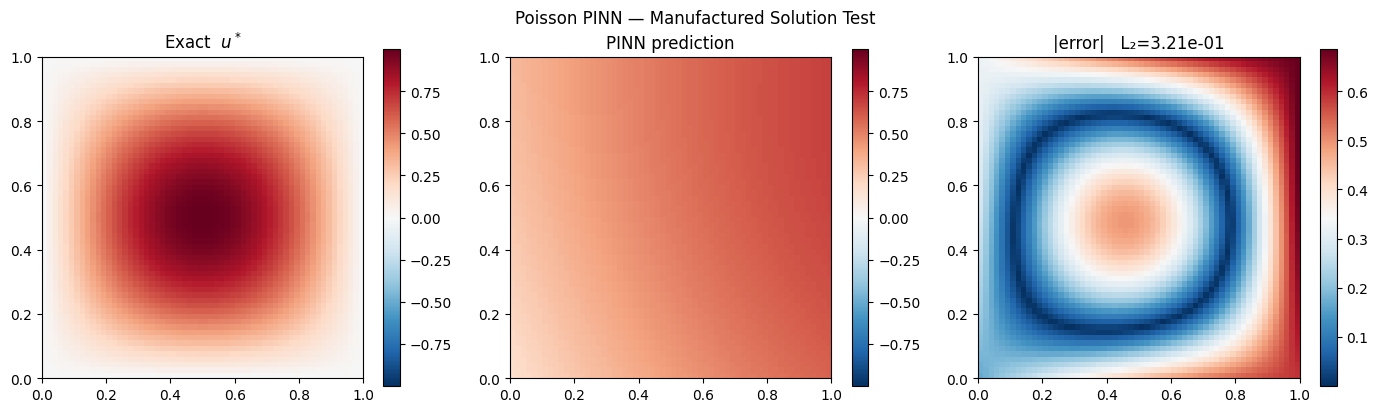

In [6]:
import numpy as np
import matplotlib.pyplot as plt

pi = math.pi
N  = 60
x1v = np.linspace(0, 1, N)
x3v = np.linspace(0, 1, N)
X1, X3 = np.meshgrid(x1v, x3v)

# Exact solution
U_exact = np.sin(pi * X1) * np.sin(pi * X3)

# PINN prediction
with torch.no_grad():
    x1t = torch.tensor(X1.ravel(), dtype=dtype).unsqueeze(1)
    x3t = torch.tensor(X3.ravel(), dtype=dtype).unsqueeze(1)
    U_pred = net_poisson(x1t, x3t).numpy().reshape(N, N)

# Error
L2_err = np.sqrt(np.mean((U_pred - U_exact)**2))
print(f"L₂ error: {L2_err:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw = dict(origin="lower", extent=[0,1,0,1], aspect="equal", cmap="RdBu_r")

vmax = U_exact.max()
im0 = axes[0].imshow(U_exact, vmin=-vmax, vmax=vmax, **kw)
axes[0].set_title("Exact  $u^*$")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred,  vmin=-vmax, vmax=vmax, **kw)
axes[1].set_title("PINN prediction")
plt.colorbar(im1, ax=axes[1])

err = np.abs(U_pred - U_exact)
im2 = axes[2].imshow(err, **kw)
axes[2].set_title(f"|error|   L₂={L2_err:.2e}")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("Poisson PINN — Manufactured Solution Test")
plt.tight_layout()
plt.show()

In [7]:
ALPHA = 0.1   # thermal diffusivity

# ── Network: inputs (x1, t)  →  output u ────────────────────────────────────
class HeatNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x1: Tensor, x3: Tensor, t: Tensor) -> Tensor:
        # x3 is unused; t is the time coordinate
        inp = torch.cat([x1, t], dim=-1)
        return self.net(inp)


# ── PDE residual: du/dt - α d²u/dx1² = 0 ─────────────────────────────────────
def heat_pde_fn(net, x1: Tensor, x3: Tensor, t: Tensor):
    # NOTE: t must have requires_grad=True for du/dt
    t.requires_grad_(True)
    u = net(x1, x3, t)
    u_t   = _grad(u, t)
    u_x1  = _grad(u, x1)
    u_x1x1 = _grad(u_x1, x1)
    residual = u_t - ALPHA * u_x1x1
    return [residual]


# ── Boundary conditions: u(0,t) = u(1,t) = 0 ─────────────────────────────────
def heat_bc(net, N: int, device, dtype, **_):
    t_rand = torch.rand(N, 1, device=device, dtype=dtype)    # t ~ U[0,1]
    zeros  = torch.zeros(N, 1, device=device, dtype=dtype)
    ones   = torch.ones (N, 1, device=device, dtype=dtype)
    x3_dummy = zeros
    u_left  = net(zeros, x3_dummy, t_rand)   # u(0,t)
    u_right = net(ones,  x3_dummy, t_rand)   # u(1,t)
    return torch.cat([u_left, u_right], dim=0)


# ── Initial condition: u(x1,0) = sin(π x1) ───────────────────────────────────
def heat_ic(net, N: int, device, dtype, **_):
    x1_rand = torch.rand(N, 1, device=device, dtype=dtype)   # x1 ~ U[0,1]
    t_zero  = torch.zeros(N, 1, device=device, dtype=dtype)
    x3_dummy = t_zero
    u_pred = net(x1_rand, x3_dummy, t_zero)
    u_exact = torch.sin(math.pi * x1_rand)
    return u_pred - u_exact


# ── Assemble the heat problem ─────────────────────────────────────────────────
heat_problem = ProblemSpec(
    name="1D Heat Equation (with Initial Condition)",
    domain=DomainSpec(
        x1_range=(0.0, 1.0),
        x3_range=(0.0, 1.0),   # x3 unused but required by DomainSpec
        t_range=(0.0, 1.0),    # ← time-dependent
    ),
    pde_fn=heat_pde_fn,
    boundary_conditions=[
        BoundaryCondition("dirichlet_zero", heat_bc, weight=10.0),
    ],
    initial_conditions=[             # ← ICs automatically used in loss
        InitialCondition("u_t0", heat_ic, weight=10.0),
    ],
)

print("Problem :", heat_problem.name)
print("Has ICs :", heat_problem.has_initial_conditions)
print("Is time-dependent:", heat_problem.is_time_dependent)

Problem : 1D Heat Equation (with Initial Condition)
Has ICs : True
Is time-dependent: True


In [8]:
net_heat  = HeatNet(hidden=64).to(device=device, dtype=dtype)
opt_heat  = torch.optim.Adam(net_heat.parameters(), lr=1e-3)

hist_heat = []
for step in range(1, 4001):
    opt_heat.zero_grad()
    loss, comps = pinn_loss(
        net_heat,
        N_int=2000, N_bc=400, N_ic=400,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=1.0,
        problem=heat_problem,     # ← different problem, same loss.py
    )
    loss.backward()
    opt_heat.step()
    hist_heat.append(float(comps["total"]))

    if step % 1000 == 0:
        print(f"Step {step:4d}  total={float(comps['total']):.4e}  "
              f"pde={float(comps['pde']):.4e}  "
              f"bc={float(comps['bc_total']):.4e}  "
              f"ic={float(comps['ic_total']):.4e}")

print("Done.")

Step 1000  total=9.7373e-04  pde=4.9830e-04  bc=2.5432e-04  ic=2.2111e-04
Step 2000  total=3.1488e-04  pde=1.6900e-04  bc=6.4079e-05  ic=8.1806e-05
Step 3000  total=2.7895e-04  pde=1.0481e-04  bc=8.4232e-05  ic=8.9913e-05
Step 4000  total=1.1681e-04  pde=9.9017e-05  bc=1.1455e-05  ic=6.3417e-06
Done.


Heat equation L₂ error: 1.0633e-03


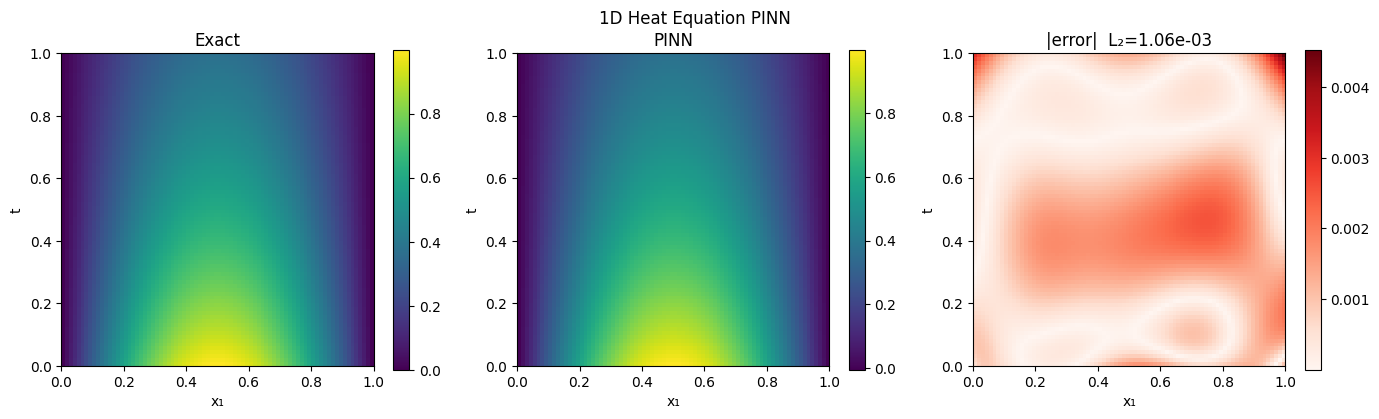

In [9]:
# ── Evaluate against exact solution ──────────────────────────────────────────
N = 80
x1v = np.linspace(0, 1, N)
tv  = np.linspace(0, 1, N)
X1h, Th = np.meshgrid(x1v, tv)

U_exact_heat = np.exp(-ALPHA * pi**2 * Th) * np.sin(pi * X1h)

with torch.no_grad():
    x1t = torch.tensor(X1h.ravel(), dtype=dtype).unsqueeze(1)
    tt  = torch.tensor(Th.ravel(),  dtype=dtype).unsqueeze(1)
    xt3 = torch.zeros_like(x1t)
    U_pred_heat = net_heat(x1t, xt3, tt).numpy().reshape(N, N)

L2_heat = np.sqrt(np.mean((U_pred_heat - U_exact_heat)**2))
print(f"Heat equation L₂ error: {L2_heat:.4e}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
kw2 = dict(origin="lower", extent=[0,1,0,1], aspect="equal", cmap="viridis")

im0 = axes[0].imshow(U_exact_heat, **kw2)
axes[0].set(title="Exact", xlabel="x₁", ylabel="t")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(U_pred_heat,  **kw2)
axes[1].set(title="PINN", xlabel="x₁", ylabel="t")
plt.colorbar(im1, ax=axes[1])

err2 = np.abs(U_pred_heat - U_exact_heat)
im2 = axes[2].imshow(err2, origin="lower", extent=[0,1,0,1], aspect="equal", cmap="Reds")
axes[2].set(title=f"|error|  L₂={L2_heat:.2e}", xlabel="x₁", ylabel="t")
plt.colorbar(im2, ax=axes[2])

plt.suptitle("1D Heat Equation PINN")
plt.tight_layout()
plt.show()

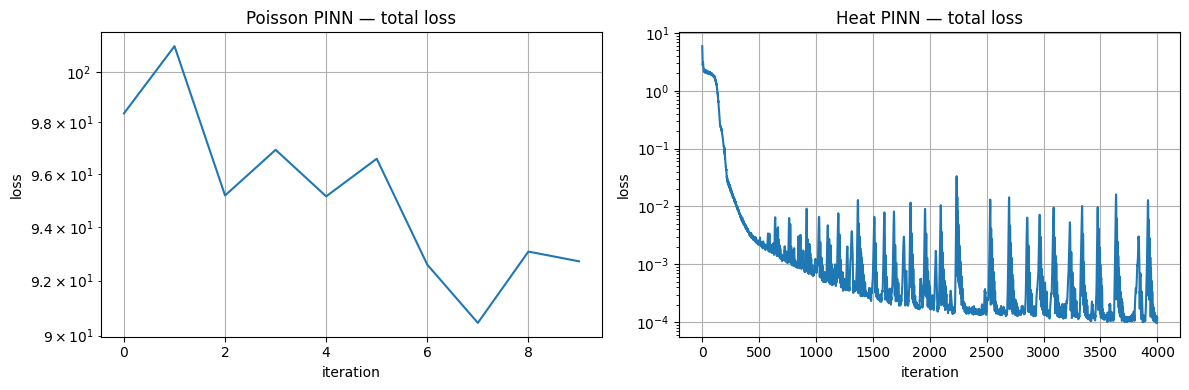

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(history)
axes[0].set(title="Poisson PINN — total loss", xlabel="iteration", ylabel="loss")
axes[0].grid(True)

axes[1].semilogy(hist_heat)
axes[1].set(title="Heat PINN — total loss", xlabel="iteration", ylabel="loss")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Added Important PINN Cells
These cells were extracted from the reference notebook and merged into the converted notebook.

In [13]:
import sys
import os

ROOT = os.getcwd()

if ROOT not in sys.path:
    sys.path.append(ROOT)

from src.network import MechanicsNet
from src.config import *
from src.sampling import *

from src.loss import pinn_loss
from src.trainer import Trainer

In [14]:
import torch
import torch.optim as optim

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cpu


In [16]:
from src import config as cfg

print("Geometry:")
print("H =", cfg.H)
print("L_TRUNC =", cfg.L_TRUNC)

print("\nCrack:")
print("A_CRACK =", cfg.A_CRACK)
print("B_CRACK =", cfg.B_CRACK)

print("\nTime:")
print("T_MAX =", cfg.T_MAX)

print("\nTraining:")
print("N_INTERIOR =", cfg.N_INTERIOR)
print("N_BOUNDARY =", cfg.N_BOUNDARY)

print("\nMaterial constants:")
print("MU_11 =", cfg.MU_11)
print("MU_33 =", cfg.MU_33)
print("EPS_11 =", cfg.EPS_11)

Geometry:
H = 4.0
L_TRUNC = 10.0

Crack:
A_CRACK = 1.0
B_CRACK = 3.0

Time:
T_MAX = 2.0

Training:
N_INTERIOR = 8000
N_BOUNDARY = 1500

Material constants:
MU_11 = 139000000000.0
MU_33 = 113000000000.0
EPS_11 = 6e-09


In [17]:
model_layer, model_half = get_all_networks()

model_layer.to(DEVICE)
model_half.to(DEVICE)


NameError: name 'get_all_networks' is not defined

In [ ]:
geom = CONFIG["GEOMETRY"]

# --------------------------------------------------
# Convert parameters to tensors (DEVICE-safe)
# --------------------------------------------------
params_layer_raw = CONFIG["LAYER"]
params_half_raw  = CONFIG["HALFSPACE"]   # ✅ CORRECT KEY (was "HALFSPACE")

params_layer = {
    kk: torch.tensor(v, device=DEVICE, dtype=torch.float32)
    if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_layer_raw.items()
}

params_half = {
    kk: torch.tensor(v, device=DEVICE, dtype=torch.float32)
    if not isinstance(v, torch.Tensor) else v.to(DEVICE)
    for kk, v in params_half_raw.items()
}

# --------------------------------------------------
# Storage for dispersion results
# --------------------------------------------------
dispersion = []

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(
    [
        # Layer network
        {"params": model_layer.parameters(), "lr": 1e-3},

        # Half-space network
        {"params": model_half.parameters(), "lr": 1e-3},

        # Eigenvalue (wave speed)
        {"params": [c], "lr": 1e-4},
    ]
)

In [ ]:
# Training Loop (Dispersion)
k_values = torch.linspace(
    CONFIG["WAVE"]["k_min"],
    CONFIG["WAVE"]["k_max"],
    CONFIG["WAVE"]["num_k"],
    device=DEVICE,
    dtype=torch.float32
)

In [ ]:
import torch
import torch.optim as optim

from src.networks import get_all_networks
from src.config import CONFIG
from src.sampling import (
    sample_domain_points,
    sample_top_surface,
    sample_interface,
    sample_far_field
)
from src.losses import total_loss

# --------------------------------------------------
# Device
# --------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --------------------------------------------------
# Geometry and parameters
# --------------------------------------------------
geom = CONFIG["GEOMETRY"]
wavenumber = CONFIG["WAVE"]

params_layer = CONFIG["LAYER"]
params_half  = CONFIG["HALFSPACE"]

# Convert to tensors
params_layer = {
    k: torch.tensor(v, dtype=torch.float32, device=DEVICE) if isinstance(v, (int, float)) else v
    for k, v in params_layer.items()
}
params_half = {
    k: torch.tensor(v, dtype=torch.float32, device=DEVICE) if isinstance(v, (int, float)) else v
    for k, v in params_half.items()
}

# --------------------------------------------------
# Build models ONCE
# --------------------------------------------------
model_layer, model_half = get_all_networks()
model_layer.to(DEVICE)
model_half.to(DEVICE)

# --------------------------------------------------
# Compute shear wave velocities
# --------------------------------------------------
c_shear_layer = torch.sqrt(params_layer["c44_star"] / params_layer["rho"])
c_shear_half  = torch.sqrt(params_half["c44_star"] / params_half["rho"])
kappa= params_layer["c44_star"]/(params_layer["s"]*params_layer["h1"]);
print("\n=== LOVE-WAVE PHYSICS CHECK ===")
print(f"c_shear_layer = {c_shear_layer.item():.3f}")
print(f"c_shear_half  = {c_shear_half.item():.3f}")
print("Constraint enforced via sigmoid")
print("================================\n")


# ==================================================
# TRAIN FUNCTION (like FGM structure)
# ==================================================
def train_for_single_k(
    k,
    model_layer,
    model_half,
    params_layer,
    params_half,
    geom,
    c_shear_layer,
    c_shear_half,
    kappa,
    prev_c=None,
    n_epochs=20,
    device="cpu"
):

    # -----------------------------
    # Bounds for c
    # -----------------------------
    lower = 0.8* c_shear_layer

    if prev_c is None:
        upper = 2.8 * c_shear_half
    else:
        upper = torch.minimum(2.8 * c_shear_half, prev_c * 0.99)

    # -----------------------------
    # Trainable parameter
    # -----------------------------
    c_raw = torch.nn.Parameter(torch.tensor(1.0, device=device))

    # -----------------------------
    # Optimizers
    # -----------------------------
    optimizer_nets = optim.Adam(
        list(model_layer.parameters()) + list(model_half.parameters()),
        lr=1e-3
    )

    optimizer_c = optim.Adam([c_raw], lr=1e-4)

    best_loss = float("inf")
    best_c = None

    # ==================================================
    # TRAINING LOOP (EPOCHS)
    # ==================================================
    for epoch in range(1, n_epochs + 1):

        # Map c using sigmoid constraint
        c = lower + torch.sigmoid(c_raw) * (upper - lower)

        # ---- sampling ----
        z_layer, z_half = sample_domain_points(2000, geom)
        z_top = sample_top_surface(500, geom)
        z_int = sample_interface(500)
        z_far = sample_far_field(500, geom)

        optimizer_nets.zero_grad()
        optimizer_c.zero_grad()

        # ---- loss ----
        loss, logs = total_loss(
            model_layer, model_half,
            z_layer, z_half,
            z_top, z_int, z_far,
            params_layer, params_half,
            k, c,kappa,
            w_pde=10.0,
           w_bc=1.0,
           w_int=1.0,
           w_far=0.1,
           w_amp=0.01
        )

        # ---- backprop ----
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(model_layer.parameters()) +
            list(model_half.parameters()) + [c_raw],
            1.0
        )

        optimizer_nets.step()
        optimizer_c.step()

        # ---- best solution ----
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_c = c.detach().item()

        # ---- stopping ----
        if loss.item() < 1e-6:
            print(f"✓ Early stop at epoch {epoch}")
            break

        # ---- logging ----
        if epoch % 100 == 0:
            print(
    f"Epoch {epoch:4d} | "
    f"Loss={loss.item():.3e} | "
    f"PDE={logs['pde']:.2e} | "
    f"TOP={logs['bc_top']:.2e} | "
    f"INT={logs['interface']:.2e} | "
    f"FAR={logs['far']:.2e} | "
    f"c={c.item():.6f}"
)

    return best_c


# ==================================================
# MAIN LOOP (Dispersion computation)
# ==================================================
k_values = torch.linspace(
    wavenumber["k_min"],
    wavenumber["k_max"],
    wavenumber["num_k"]
)

dispersion = []

print(f"Training over {len(k_values)} k values...\n")

for idx, k in enumerate(k_values):

    k = k.to(DEVICE)

    print(f"\n{'='*60}")
    print(f"[{idx+1}/{len(k_values)}] Training for k = {k.item():.4f}")
    print(f"{'='*60}")

    prev_c = None if idx == 0 else torch.tensor(dispersion[-1][1], device=DEVICE)

    c_val = train_for_single_k(
        k,
        model_layer,
        model_half,
        params_layer,
        params_half,
        geom,
        c_shear_layer,
        c_shear_half,
        kappa,
        prev_c=prev_c,
        n_epochs=5000,
        device=DEVICE
    )

    dispersion.append([k.item(), c_val])

    print(f"✓ Final c(k={k.item():.4f}) = {c_val:.6f}")

# --------------------------------------------------
# Save dispersion
# --------------------------------------------------
torch.save(dispersion, "final_dispersion.pt")

print("\n✓ Training complete!")
print("Saved: final_dispersion.pt")

In [ ]:
# k0 = list(loss_history_all.keys())[0]
# print(len(loss_history_all[k0]["total"]))

In [ ]:
# # ============================================
# # LOSS DISTRIBUTION BOXPLOT
# # ============================================

# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Rectangle

# # ============================================
# # Extract losses
# # ============================================

# total_loss = np.array(
#     loss_history_all["total"]
# )

# pde_loss = np.array(
#     loss_history_all["pde"]
# )

# int_loss = np.array(
#     loss_history_all["interface"]
# )

# # Avoid log-scale issues
# total_loss = np.clip(total_loss, 1e-16, None)

# pde_loss = np.clip(pde_loss, 1e-16, None)

# int_loss = np.clip(int_loss, 1e-16, None)

# # ============================================
# # Combine
# # ============================================

# loss_data = [
#     total_loss,
#     pde_loss,
#     int_loss
# ]

# # ============================================
# # Statistics
# # ============================================

# means = [np.mean(d) for d in loss_data]

# stds = [np.std(d) for d in loss_data]

# mins = [np.min(d) for d in loss_data]

# maxs = [np.max(d) for d in loss_data]

# finals = [d[-1] for d in loss_data]

# # ============================================
# # Figure
# # ============================================

# plt.figure(figsize=(10,5))

# bp = plt.boxplot(
#     loss_data,

#     labels=['Total', 'PDE', 'Interface'],

#     patch_artist=True,

#     showmeans=True,

#     medianprops=dict(
#         color='orange',
#         linewidth=2
#     ),

#     meanprops=dict(
#         marker='D',
#         markerfacecolor='green',
#         markeredgecolor='white',
#         markersize=7
#     ),

#     flierprops=dict(
#         marker='o',
#         markerfacecolor='gray',
#         markersize=3,
#         alpha=0.3
#     )
# )

# # ============================================
# # Colors
# # ============================================

# colors = [
#     'gray',
#     'blue',
#     'green'
# ]

# for patch, color in zip(bp['boxes'], colors):

#     patch.set_facecolor(color)

#     patch.set_alpha(0.4)

# # ============================================
# # Labels
# # ============================================

# plt.ylabel(
#     'Loss value (log scale)',
#     fontsize=12
# )

# plt.yscale('log')

# plt.grid(
#     True,
#     linestyle=':',
#     alpha=0.5
# )

# # ============================================
# # Legend
# # ============================================

# legend_handles = [

#     Rectangle((0,0),1,1,
#               facecolor='gray',
#               alpha=0.4),

#     Rectangle((0,0),1,1,
#               facecolor='blue',
#               alpha=0.4),

#     Rectangle((0,0),1,1,
#               facecolor='green',
#               alpha=0.4)
# ]

# legend_labels = [

#     f'Total Loss (μ={means[0]:.2e}, σ={stds[0]:.2e})',

#     f'PDE Loss (μ={means[1]:.2e}, σ={stds[1]:.2e})',

#     f'Interface Loss (μ={means[2]:.2e}, σ={stds[2]:.2e})'
# ]

# plt.legend(
#     legend_handles,
#     legend_labels,
#     loc='center left',
#     bbox_to_anchor=(1.02, 0.5),
#     fontsize=9
# )

# # ============================================
# # Statistics box
# # ============================================

# stats_text = (

#     "STATISTICS\n\n"

#     "FINAL VALUES:\n"

#     f"Total: {finals[0]:.2e}\n"

#     f"PDE: {finals[1]:.2e}\n"

#     f"Int: {finals[2]:.2e}\n\n"

#     "MEAN:\n"

#     f"Total: {means[0]:.2e}\n"

#     f"PDE: {means[1]:.2e}\n"

#     f"Int: {means[2]:.2e}\n\n"

#     "STD DEV:\n"

#     f"Total: {stds[0]:.2e}\n"

#     f"PDE: {stds[1]:.2e}\n"

#     f"Int: {stds[2]:.2e}\n\n"

#     "MIN:\n"

#     f"Total: {mins[0]:.2e}\n"

#     f"PDE: {mins[1]:.2e}\n"

#     f"Int: {mins[2]:.2e}\n\n"

#     "MAX:\n"

#     f"Total: {maxs[0]:.2e}\n"

#     f"PDE: {maxs[1]:.2e}\n"

#     f"Int: {maxs[2]:.2e}"
# )

# props = dict(
#     boxstyle='round',
#     facecolor='#f0f0f0',
#     edgecolor='black',
#     alpha=0.9
# )

# plt.gcf().text(
#     0.02,
#     0.8,
#     stats_text,
#     fontsize=8,
#     verticalalignment='top',
#     bbox=props
# )

# plt.subplots_adjust(
#     left=0.25,
#     right=0.75
# )

# plt.show()

# # plt.grid(True)

# # plt.show()

In [ ]:
torch.save({
    "model_layer": model_layer.state_dict(),
    "model_half": model_half.state_dict(),
    "c": c.detach().cpu()
}, "dispersion_pinn.pth")

print("Model saved.")


In [ ]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

L = geom["h1"]   # layer thickness (✅ corrected key: was "L")
H_trunc = geom["H_trunc"]   # half-space depth

In [ ]:
# z-grid for plotting / post-processing

z_layer = torch.linspace(-L, 0.0, 200).reshape(-1, 1).to(DEVICE)
z_half  = torch.linspace(0.0, H_trunc, 200).reshape(-1, 1).to(DEVICE)



In [ ]:
import sys, platform
import torch
print("sys.executable:", sys.executable)
print("python:", platform.python_version())
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

In [ ]:
import matplotlib.pyplot as plt
import torch

# dispersion: shape (N, 2) → [k, c]
dispersion = torch.tensor(dispersion)
# dispersion: shape (N, 2) → [k, c]
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]


plt.figure(figsize=(6,5))
plt.plot(k_vals, c_vals, 'o-', linewidth=2, markersize=6)

plt.xlabel("Wave number $k$")
plt.ylabel("Phase velocity $c$")
plt.title("Dispersion Relation")
plt.grid(True)

plt.show()



In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Your dispersion data
dispersion = torch.tensor(dispersion)
k_vals = dispersion[:, 0]
c_vals = dispersion[:, 1]

# Material properties for layer (from your config)
mu44_layer = 7.511e9 # Pa
rho_layer = 3949.0 # kg/m³
H = 20 # Layer thickness (non-dimensional)

# Calculate reference velocity: √(μ₆₆/ρ) for layer
c_ref_layer = np.sqrt(mu44_layer / rho_layer)# Reference shear speed

print(f"Layer properties:")
print(f"  μ₄₄ = {mu44_layer:.2e} Pa")
print(f"  ρ = {rho_layer:.0f} kg/m³")
print(f"  c_ref = √(μ₄₄/ρ) = {c_ref_layer:.1f} m/s")
print(f"  H = {H}")

# Non-dimensionalize
kH = k_vals * H                     # Dimensionless wavenumber
c_norm = c_vals / c_ref_layer       # Dimensionless phase velocity

# Plot
plt.figure(figsize=(6, 5))
plt.plot(kH, c_norm, 'o-', linewidth=2, markersize=6)

plt.xlabel("Dimensionless wavenumber $kH$")
plt.ylabel("Dimensionless phase velocity $c/\\sqrt{\\mu_{44}/\\rho}$")
plt.title("Dispersion Relation (Non-dimensional)")
plt.grid(True)

plt.show()

# Print the data
print("\nDispersion data (non-dimensional):")
print("   kH        c/c_ref")
for i in range(len(kH)):
    print(f"   {kH[i]:.3f}     {c_norm[i]:.3f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# Convert tensors to numpy
kH_np = kH.cpu().numpy() if hasattr(kH, 'cpu') else np.array(kH)

c_norm_np = c_norm.cpu().numpy() if hasattr(c_norm, 'cpu') else np.array(c_norm)

# Sort
sort_idx = np.argsort(kH_np)

kH_sorted = kH_np[sort_idx]

c_norm_sorted = c_norm_np[sort_idx]

# Remove duplicate x-values
kH_sorted, unique_idx = np.unique(
    kH_sorted,
    return_index=True
)

c_norm_sorted = c_norm_sorted[unique_idx]

# Smooth curve
kH_smooth = np.linspace(
    kH_sorted.min(),
    kH_sorted.max(),
    300
)

spline = make_interp_spline(
    kH_sorted,
    c_norm_sorted,
    k=2
)

c_norm_smooth = spline(kH_smooth)

# Plot
plt.figure(figsize=(6,5))

plt.plot(
    kH_sorted,
    c_norm_sorted,
    'o',
    label='Discrete points'
)

plt.plot(
    kH_smooth,
    c_norm_smooth,
    '-',
    linewidth=2,
    label='Smooth curve'
)

plt.xlabel(r"Dimensionless wavenumber ($kh_{1}$)")

plt.ylabel(
    r"Dimensionless phase velocity ($c/\sqrt{\mu_{44}/\rho}$)"
)

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
# Save PINN dispersion data
np.savetxt(
    "PINN_dispersion.csv",
    np.column_stack((kH_sorted, c_norm_sorted)),
    delimiter=",",
    header="kh_1,c_pinn",
    comments=""
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Parameters (same as MATLAB)
# ----------------------------------------
h1 = 20
s = 10000
sigma1 = 1e11
sigma2 = 1e11
e15R1 = -0.0919

# Constants
c44R1 = 7.511e9
c44R2 = 8.172e9
c44I1 = 9.7252e9
c44I2 = 32.239e9

a11R1 = -0.3041e-9
a11I1 = -0.02e-12
a11I2 = -2.55e-12
a11R2 = -0.4187e-9

e15R2 = -0.0968
e15I1 = -0.000285
e15I2 = -0.0003

rho1 = 3949
rho2 = 3259

# ----------------------------------------
# Grid (like your second code)
# ----------------------------------------
x = np.linspace(0.026, 0.12, 200)
y = np.linspace(1.0, 2.5, 200)

X, Y = np.meshgrid(x, y)

# ----------------------------------------
# Derived quantities
# ----------------------------------------
beta1 = np.sqrt(c44R1 / rho1)
w = (X * Y * beta1) / h1

c44n = (c44R1 - 1j*w*c44I1) + ((e15R1 - 1j*w*e15I1)**2 / (a11R1 - 1j*w*a11I1))
c44t = (c44R2 - 1j*w*c44I2) + ((e15R2 - 1j*w*e15I2)**2 / (a11R2 - 1j*w*a11I2))

km = c44t / (s * h1)

lambdau = np.sqrt((rho1 * (Y**2 * beta1**2))/c44n - sigma1/c44n - 1)
lambdal = np.sqrt(1 - (rho2*(Y**2*beta1**2))/c44t + sigma2/c44t)

# ----------------------------------------
# Matrix determinant computation
# ----------------------------------------
F = np.zeros_like(X, dtype=float)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):

        xi = X[i, j]
        yi = Y[i, j]
        wi = w[i, j]

        # Local values
        lam_u = lambdau[i, j]
        lam_l = lambdal[i, j]

        c44n_ = c44n[i, j]
        c44t_ = c44t[i, j]
        km_ = km[i, j]

        # Matrix elements (same as MATLAB)
        P11 = -(e15R1-1j*wi*e15I1)*(xi/h1)*np.exp(xi)
        P12 = (e15R1-1j*wi*e15I1)*(xi/h1)*np.exp(-xi)

        P13 = (c44n_*(xi/h1)*lam_u*np.cos(xi*lam_u))
        P14 = (c44n_*(xi/h1)*lam_u*np.sin(xi*lam_u))

        P21 = np.exp(xi)
        P22 = np.exp(-xi)
        P23 = -(e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)*np.sin(xi*lam_u)
        P24 = (e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)*np.cos(xi*lam_u)

        P31 = -(e15R1-1j*wi*e15I1)*(xi/h1)
        P32 = (e15R1-1j*wi*e15I1)*(xi/h1)
        P33 = c44n_*(xi/h1)*lam_u

        P35 = -(e15R2-1j*wi*e15I2)*(xi/h1)
        P36 = -(c44t_*(xi/h1)*lam_l)

        P41 = 0
        P44 = km_
        P45 = (e15R2-1j*wi*e15I2)*(xi/h1)
        P46 = c44t_*(xi/h1)*lam_l - km_

        P51 = 1
        P52 = 1
        P54 = (e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)
        P55 = -1
        P56 = -(e15R2-1j*wi*e15I2)/(a11R2-1j*wi*a11I2)

        P61 = (a11R1-1j*wi*a11I1)*(xi/h1)
        P62 = -(a11R1-1j*wi*a11I1)*(xi/h1)
        P65 = (a11R2-1j*wi*a11I2)*(xi/h1)
        P66 = -(e15R2-1j*wi*e15I2)*(xi/h1)*lam_l

        matrix = np.array([
            [P11, P12, P13, P14, 0, 0],
            [P21, P22, P23, P24, 0, 0],
            [P31, P32, P33, 0,   P35, P36],
            [0,   0,   0,   P44, P45, P46],
            [P51, P52, 0,   P54, P55, P56],
            [P61, P62, 0,   0,   P65, P66]
        ])

        F[i, j] = np.real(np.linalg.det(matrix))

# ----------------------------------------
# Plot (same style as your second code)
# ----------------------------------------
plt.figure(figsize=(7,5))
plt.contour(X, Y, F, levels=[0], colors='k')

plt.xlabel(r'$kh_1$')
plt.ylabel(r'$c/\beta_l$')
plt.ylim([1, 2.5])
plt.grid(True)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.lib.scimath import sqrt
from scipy.interpolate import make_interp_spline

# ==============================
# LOAD PINN DATA
# ==============================
pinn = np.loadtxt("PINN_dispersion.csv", delimiter=",", skiprows=1)
kH = pinn[:, 0]
c_pinn = pinn[:, 1]

# ==============================
# PARAMETERS (from your MATLAB code)
# ==============================
h1 = 20
s = 10000
sigma1 = 1e11
sigma2 = 1e11
e15R1 = -0.0919

c44R1 = 7.511e9
c44R2 = 8.172e9
c44I1 = 9.7252e9
c44I2 = 32.239e9

a11R1 = -0.3041e-9
a11I1 = -0.02e-12
a11I2 = -2.55e-12
a11R2 = -0.4187e-9

e15R2 = -0.0968
e15I1 = -0.000285
e15I2 = -0.0003

rho1 = 3949
rho2 = 3259

beta1 = np.sqrt(c44R1 / rho1)

# ==============================
# GRID
# ==============================
x = np.linspace(0.026, 0.12, 200)
y = np.linspace(1.0, 2.5, 200)

X, Y = np.meshgrid(x, y)

# ==============================
# ANALYTICAL (DET MODEL)
# ==============================
w = (X * Y * beta1) / h1

c44n = (c44R1 - 1j*w*c44I1) + ((e15R1 - 1j*w*e15I1)**2 / (a11R1 - 1j*w*a11I1))
c44t = (c44R2 - 1j*w*c44I2) + ((e15R2 - 1j*w*e15I2)**2 / (a11R2 - 1j*w*a11I2))

km = c44t / (s * h1)

lambdau = sqrt((rho1*(Y**2*beta1**2))/c44n - sigma1/c44n - 1)
lambdal = sqrt(1 - (rho2*(Y**2*beta1**2))/c44t + sigma2/c44t)

F = np.zeros_like(X, dtype=float)

# ---- determinant computation ----
for i in range(X.shape[0]):
    for j in range(X.shape[1]):

        xi = X[i, j]
        yi = Y[i, j]
        wi = w[i, j]

        lam_u = lambdau[i, j]
        lam_l = lambdal[i, j]

        c44n_ = c44n[i, j]
        c44t_ = c44t[i, j]
        km_ = km[i, j]

        P11 = -(e15R1-1j*wi*e15I1)*(xi/h1)*np.exp(xi)
        P12 = (e15R1-1j*wi*e15I1)*(xi/h1)*np.exp(-xi)

        P13 = c44n_*(xi/h1)*lam_u*np.cos(xi*lam_u)
        P14 = c44n_*(xi/h1)*lam_u*np.sin(xi*lam_u)

        P21 = np.exp(xi)
        P22 = np.exp(-xi)
        P23 = -(e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)*np.sin(xi*lam_u)
        P24 = (e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)*np.cos(xi*lam_u)

        P31 = -(e15R1-1j*wi*e15I1)*(xi/h1)
        P32 = (e15R1-1j*wi*e15I1)*(xi/h1)
        P33 = c44n_*(xi/h1)*lam_u

        P35 = -(e15R2-1j*wi*e15I2)*(xi/h1)
        P36 = -(c44t_*(xi/h1)*lam_l)

        P44 = km_
        P45 = (e15R2-1j*wi*e15I2)*(xi/h1)
        P46 = c44t_*(xi/h1)*lam_l - km_

        P51 = 1
        P52 = 1
        P54 = (e15R1-1j*wi*e15I1)/(a11R1-1j*wi*a11I1)
        P55 = -1
        P56 = -(e15R2-1j*wi*e15I2)/(a11R2-1j*wi*a11I2)

        P61 = (a11R1-1j*wi*a11I1)*(xi/h1)
        P62 = -(a11R1-1j*wi*a11I1)*(xi/h1)
        P65 = (a11R2-1j*wi*a11I2)*(xi/h1)
        P66 = -(e15R2-1j*wi*e15I2)*(xi/h1)*lam_l

        matrix = np.array([
            [P11, P12, P13, P14, 0, 0],
            [P21, P22, P23, P24, 0, 0],
            [P31, P32, P33, 0,   P35, P36],
            [0,   0,   0,   P44, P45, P46],
            [P51, P52, 0,   P54, P55, P56],
            [P61, P62, 0,   0,   P65, P66]
        ])

        F[i, j] = np.real(np.linalg.det(matrix))

# ==============================
# EXTRACT CONTOUR
# ==============================
cs = plt.contour(X, Y, F, levels=[0])

kH_ana = []
c_ana = []

for seg in cs.allsegs[0]:
    kH_ana.extend(seg[:, 0])
    c_ana.extend(seg[:, 1])

kH_ana = np.array(kH_ana)
c_ana = np.array(c_ana)

plt.clf()

# ==============================
# SORT analytical
# ==============================
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ==============================
# SMOOTH PINN
# ==============================
# ==============================
# SMOOTH PINN
# ==============================

# Sort PINN data
idx_p = np.argsort(kH)

kH_sorted = kH[idx_p]

c_pinn_sorted = c_pinn[idx_p]

# Remove duplicate kH values
kH_unique, unique_idx = np.unique(
    kH_sorted,
    return_index=True
)

c_pinn_unique = c_pinn_sorted[unique_idx]

# Smooth spline
kH_smooth = np.linspace(
    kH_unique.min(),
    kH_unique.max(),
    300
)

spline = make_interp_spline(
    kH_unique,
    c_pinn_unique,
    k=2
)

c_pinn_smooth = spline(kH_smooth)

# ==============================
# FINAL PLOT
# ==============================
plt.figure(figsize=(7,5))

# PINN
plt.plot(
    kH_smooth,
    c_pinn_smooth,
    '--',
    linewidth=2.5,
    color='magenta',
    label='PINN'
)
plt.plot(
    kH,
    c_pinn,
    'o',
    markersize=5,
    color='blue'
)

# Analytical (determinant)
plt.plot(
    kH_ana,
    c_ana,
    color='black',
    linewidth=3,
    label='Analytical'
)

plt.xlabel(r'$kh_1$', fontsize=12)
plt.ylabel(r'$c/\beta_l$', fontsize=12)

plt.ylim([1, 2.6])
plt.xlim([0.026, 0.12])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# ERROR COMPUTATION (CORRECT WAY)
# ==============================

import numpy as np

# ---- Ensure analytical data is sorted ----
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# ---- Interpolate analytical solution onto PINN kH ----
c_ana_interp = np.interp(kH, kH_ana, c_ana)

# ---- Compute errors ----
abs_error = np.abs(c_pinn - c_ana_interp)
rel_error = abs_error / np.abs(c_ana_interp)

# ==============================
# PRINT TABLE
# ==============================
print("\nCOMPARISON TABLE")
print("kh1        PINN c/βl​   Analytical c/βl​   Abs. Error   Rel. Error")

for i in range(len(kH)):
    print(f"{kH[i]:.4f}   {c_pinn[i]:.6f}   {c_ana_interp[i]:.6f}   {abs_error[i]:.3e}   {rel_error[i]:.3e}")

# ==============================
# SAVE CSV (FOR PAPER)
# ==============================
table = np.column_stack((kH, c_pinn, c_ana_interp, abs_error, rel_error))

np.savetxt(
    "comparison_table.csv",
    table,
    delimiter=",",
    header="kH,PINN_c/cs,Analytical_c/cs,Abs_Error,Rel_Error",
    comments=""
)

print("\nSaved: comparison_table.csv")

# ==============================
# ERROR METRICS (IMPORTANT FOR PAPER)
# ==============================
rmse = np.sqrt(np.mean(abs_error**2))
mae = np.mean(abs_error)
max_err = np.max(abs_error)

print("\nError Metrics:")
print(f"RMSE = {rmse:.4e}")
print(f"MAE  = {mae:.4e}")
print(f"Max Error = {max_err:.4e}")

In [ ]:
plt.figure(figsize=(7,4))

plt.plot(kH, abs_error, 'o-', linewidth=2, markersize=4)
plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('Absolute Error', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# Absolute error contour (fixed)
# ==============================

# artificial vertical axis
y = np.linspace(0, 1, 50)

# create meshgrid using PINN kH
KH, Y = np.meshgrid(kH, y)

# repeat error along vertical direction
Z = np.tile(abs_error, (len(y), 1))

# ==============================
# PLOT
# ==============================
plt.figure(figsize=(7,4))

cont = plt.contourf(KH, Y, Z, levels=40, cmap='plasma')
cbar = plt.colorbar(cont)
cbar.set_label('Absolute Error')

plt.xlabel(r'$kH$', fontsize=12)
plt.ylabel('', fontsize=10)
plt.yticks([])

plt.xlim([min(kH), max(kH)])
plt.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ==============================
# PREPARE CORRECT ARRAYS
# ==============================
# ensure analytical is sorted
idx = np.argsort(kH_ana)
kH_ana = kH_ana[idx]
c_ana = c_ana[idx]

# interpolate analytical onto PINN kH
c_ana_interp = np.interp(kH, kH_ana, c_ana)

pred = np.asarray(c_pinn).flatten()
true = np.asarray(c_ana_interp).flatten()

# ==============================
# ERROR COMPUTATION
# ==============================
err = pred - true
abs_err = np.abs(err)

L1   = np.mean(abs_err)
RMSE = np.sqrt(np.mean(err**2))
L2   = np.sqrt(np.sum(err**2))
Linf = np.max(abs_err)
relL2 = L2 / np.sqrt(np.sum(true**2))

labels = ['L1', 'RMSE', 'L2 norm', 'L∞', 'Rel L2']
values = [L1, RMSE, L2, Linf, relL2]

In [ ]:
# ============================================
# HEATMAP OF RELATIVE ERROR
# ============================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Example architecture errors
# Replace these with your actual errors
# ------------------------------------------------

error_data = np.array([

    [0.00633, 0.00630, 0.00629],

    [0.00634, 0.00626, 0.00625],

    [0.00627, 0.00628, 0.00629],

    [0.00629, 0.00630, 0.00631]
])

# ------------------------------------------------
# Labels
# ------------------------------------------------

x_labels = [
    'N20_err',
    'N30_err',
    'N40_err'
]

y_labels = [
    '3',
    '4',
    '5',
    '6'
]

# ------------------------------------------------
# Plot
# ------------------------------------------------

plt.figure(figsize=(6,5))

im = plt.imshow(
    error_data,
    cmap='viridis',
    aspect='auto'
)

# Axis ticks
plt.xticks(
    np.arange(len(x_labels)),
    x_labels
)

plt.yticks(
    np.arange(len(y_labels)),
    y_labels
)

# Labels
plt.ylabel(
    'Hidden Layers',
    fontsize=12
)

# Colorbar
cbar = plt.colorbar(im)

cbar.set_label(
    'Relative error',
    fontsize=11
)

plt.tight_layout()

plt.show()